# 03 · Regressão logística com WoE e scorecard de pontos

Este é o modelo "clássico" de crédito, o que bancos e cooperativas usam há décadas. A regressão logística sobre variáveis em WoE tem duas vantagens que pesam muito numa instituição regulada: dá para explicar cada ponto do score para um auditor ou para o próprio cliente, e ela vira uma tabela de pontos que qualquer analista de crédito consegue ler.

O caminho aqui é:

1. agrupar à mão as faixas do [notebook 02](02_features.ipynb) para que o risco suba ou desça de forma consistente (*coarse classing*);
2. escolher as variáveis comparando alternativas na validação;
3. treinar o modelo e medir AUC, Gini e KS;
4. transformar os coeficientes num scorecard de pontos.

A base de teste continua guardada. Todas as escolhas aqui são feitas olhando só treino e validação.

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve

from credit_scoring.data import PROCESSED_DIR, ROOT, TARGET
from credit_scoring.features import FEATURES
from credit_scoring.metrics import band_table, evaluate
from credit_scoring.plotting import BLUE, GRAY, ORANGE, savefig, set_style
from credit_scoring.reporting import update_metrics
from credit_scoring.scorecard import (
    BASE_ODDS, BASE_SCORE, COARSE_EDGES, PDO, SCORECARD_FEATURES,
    build_scorecard, make_logistic_pipeline, score, score_points,
)
from credit_scoring.woe import MISSING, WoEEncoder

set_style()
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

train = pd.read_parquet(PROCESSED_DIR / "train.parquet")
val = pd.read_parquet(PROCESSED_DIR / "val.parquet")
y_train, y_val = train[TARGET], val[TARGET]
print(f"treino: {len(train):,} | validação: {len(val):,}")

treino: 105,000 | validação: 22,500


## 1. Agrupando as faixas

Para escolher os cortes, olhei a taxa de default em faixas bem finas (cerca de 20 por variável) e juntei as vizinhas com risco parecido, respeitando três critérios:

- o risco deve andar numa direção só, quando isso fizer sentido de negócio;
- cada faixa precisa ter gente suficiente (bem acima de 1% da base) para o WoE ser estável;
- os cortes devem ser fáceis de explicar ("até 33 anos", "usa mais de 90% do limite").

Os cortes escolhidos ficam em `COARSE_EDGES`, em `src/credit_scoring/scorecard.py`, para que os próximos notebooks usem exatamente os mesmos.

In [2]:
pd.Series({k: v for k, v in COARSE_EDGES.items()}, name="limites superiores das faixas").to_frame()

,limites superiores das faixas
revolving_util,"[0, 0.05, 0.13, 0.23, 0.39, 0.5, 0.7, 0.9, 1.0]"
age,"[33, 40, 48, 53, 56, 62, 69]"
debt_ratio,"[0.4256, 0.5246, 0.7127, 0.9491]"
late_30_59,"[0, 1, 2]"
late_60_89,"[0, 1]"
late_90,"[0, 1]"
real_estate_loans,"[0, 2]"


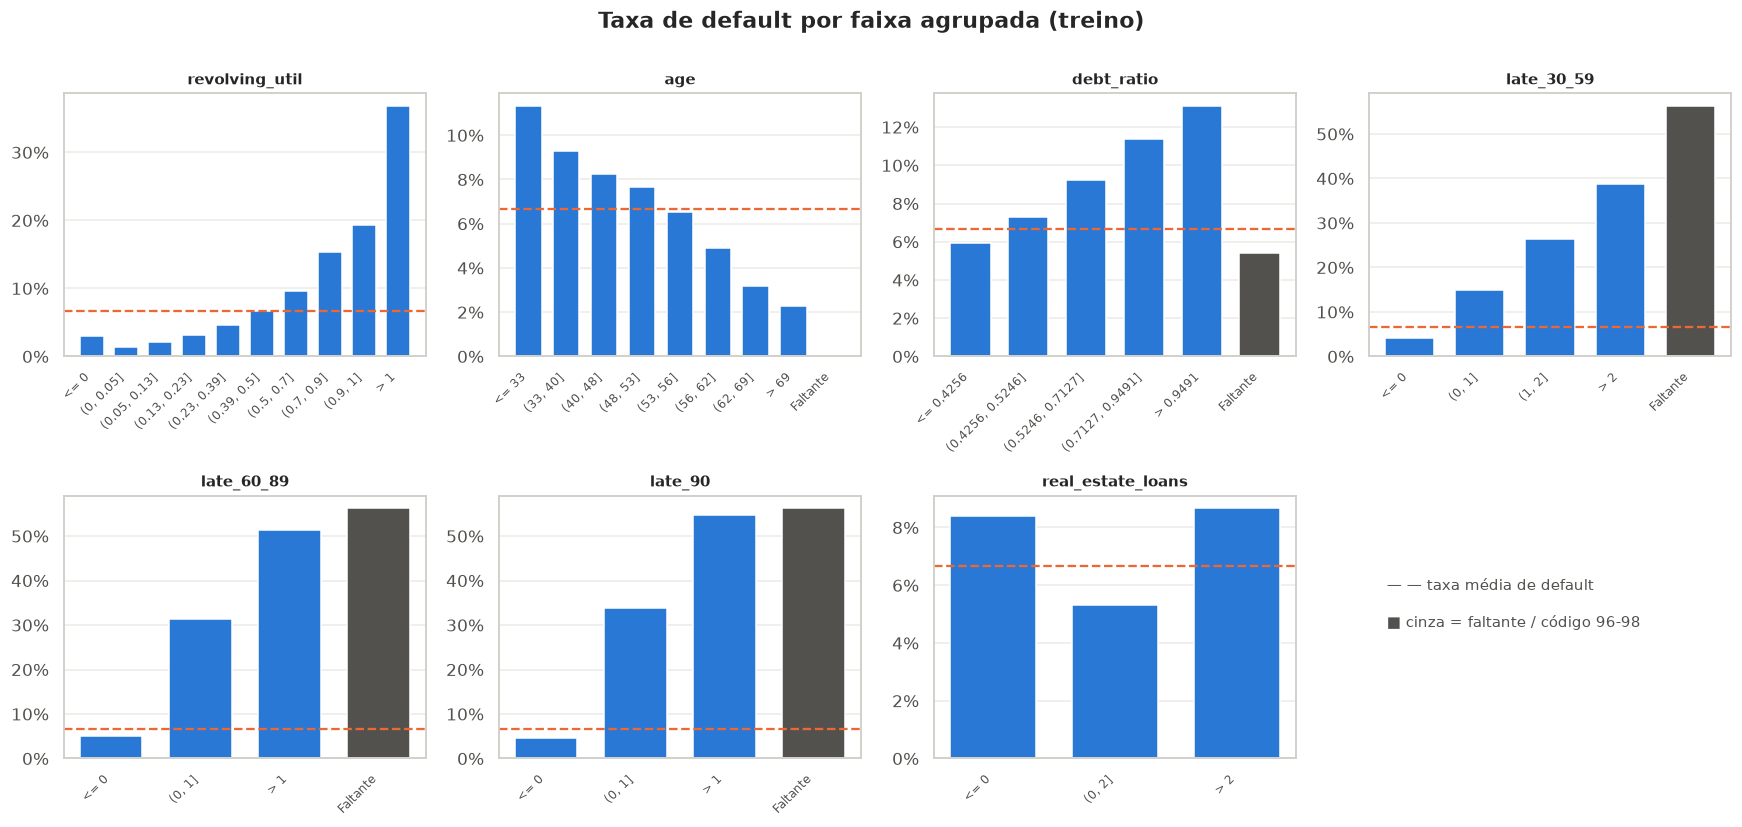

In [3]:
coarse = WoEEncoder(edges=COARSE_EDGES).fit(train[SCORECARD_FEATURES], y_train)

def plot_bad_rate(ax, table, title):
    colors = [GRAY if b == MISSING else BLUE for b in table["bin"]]
    ax.bar(range(len(table)), table["bad_rate"], color=colors, width=0.7)
    ax.axhline(y_train.mean(), color=ORANGE, lw=1.5, ls="--")
    ax.set_xticks(range(len(table)))
    ax.set_xticklabels(table["bin"].astype(str), rotation=45, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_title(title, fontsize=10)
    ax.grid(axis="x", visible=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))
for ax, col in zip(axes.flat, SCORECARD_FEATURES):
    plot_bad_rate(ax, coarse.tables_[col], col)
axes.flat[-1].axis("off")
axes.flat[-1].text(0.05, 0.5, "— — taxa média de default\n\n■ cinza = faltante / código 96-98",
                   color=GRAY, fontsize=10, transform=axes.flat[-1].transAxes)
fig.suptitle("Taxa de default por faixa agrupada (treino)", fontweight="bold", y=1.0)
fig.tight_layout()
savefig(fig, "logistic_coarse_bins")
plt.show()

A idade, o `debt_ratio` e as três colunas de atraso ficaram monotônicas. Em `debt_ratio` tudo abaixo de 0,43 virou uma faixa só: nas faixas finas o risco ali oscilava sem padrão, e separar só adicionaria ruído.

Deixei duas exceções de propósito. Em `revolving_util`, quem usa **zero** do limite tem mais risco do que quem usa um pouco. Isso tem uma explicação razoável (cliente sem histórico recente, ou que teve o cartão cortado), então mantive a faixa separada em vez de forçar a monotonia. E `real_estate_loans` ficou com três faixas em forma de U: não ter financiamento imobiliário ou ter mais de dois é mais arriscado do que ter um ou dois.

## 2. Quais variáveis entram

Testei alguns conjuntos na validação. O ponto de partida são as seis variáveis com sinal claro no notebook 02 (utilização do rotativo, idade, `debt_ratio` e as três colunas de atraso). A partir delas, vejo se vale a pena adicionar as mais fracas, e comparo também contra o `total_late` no lugar das três colunas e contra as faixas automáticas.

In [4]:
CORE = ["revolving_util", "age", "debt_ratio", "late_30_59", "late_60_89", "late_90"]
EXTRA_EDGES = {
    "income_per_person": [1203, 1792, 2300, 3125, 4300, 10000],
    "open_credit_lines": [2, 3, 5],
    "dependents": [0, 1, 2],
    "total_late": [0, 1, 2, 3],
}
all_edges = {**COARSE_EDGES, **EXTRA_EDGES}
no_late = [c for c in CORE if not c.startswith("late")]

candidates = {
    "núcleo (6)": (CORE, all_edges),
    "núcleo + real_estate_loans": (CORE + ["real_estate_loans"], all_edges),
    "  + dependents": (CORE + ["real_estate_loans", "dependents"], all_edges),
    "  + income_per_person": (CORE + ["real_estate_loans", "income_per_person"], all_edges),
    "  + open_credit_lines": (CORE + ["real_estate_loans", "open_credit_lines"], all_edges),
    "total_late no lugar dos 3 atrasos": (no_late + ["total_late", "real_estate_loans"], all_edges),
    "mesmas 7, faixas automáticas": (CORE + ["real_estate_loans"], None),
}

rows = []
for name, (cols, edges) in candidates.items():
    pipe = make_logistic_pipeline(edges={c: edges[c] for c in cols} if edges else {}).fit(train[cols], y_train)
    coefs = pipe.named_steps["logreg"].coef_[0]
    rows.append({
        "conjunto": name, "n_vars": len(cols),
        **{f"{k}_val": v for k, v in evaluate(y_val, pipe.predict_proba(val[cols])[:, 1]).items()},
        "menor |β|": np.abs(coefs).min(),
        "sinais ok": bool((coefs < 0).all()),
    })
comparison = pd.DataFrame(rows).set_index("conjunto")
comparison

,n_vars,auc_val,gini_val,ks_val,menor |β|,sinais ok
conjunto,,,,,,
núcleo (6),6,0.860,0.721,0.568,0.370,True
núcleo + real_estate_loans,7,0.861,0.723,0.565,0.370,True
+ dependents,8,0.861,0.722,0.566,0.228,True
+ income_per_person,8,0.861,0.722,0.564,0.064,True
+ open_credit_lines,8,0.861,0.723,0.565,0.020,True
total_late no lugar dos 3 atrasos,5,0.862,0.724,0.567,0.394,True
"mesmas 7, faixas automáticas",7,0.859,0.717,0.560,0.398,True


As diferenças de AUC entre os conjuntos são pequenas, na terceira casa decimal. Então o critério de desempate é simplicidade e estabilidade.

- `real_estate_loans` melhora um pouco o núcleo e entra com um coeficiente relevante.
- `dependents`, `income_per_person` e `open_credit_lines` não melhoram a validação, e o coeficiente delas sai pequeno (veja a coluna "menor |β|"). Ou seja, o modelo quase não as usa, porque o que elas dizem já está nas outras variáveis. No caso da renda isso é bem concreto: quem não informou renda já cai na faixa "Faltante" do `debt_ratio`.
- `total_late` dá praticamente o mesmo AUC que as três colunas de atraso, com menos variáveis. Mantive as três separadas porque um atraso de 90 dias é bem mais grave que um de 30, e essa diferença importa quando for preciso explicar uma recusa.
- As faixas agrupadas à mão ganham das automáticas, mesmo com menos faixas. Esse é o resultado que eu esperava: faixas maiores e coerentes generalizam melhor.

O modelo final fica com 7 variáveis.

## 3. Modelo final

In [5]:
pipeline = make_logistic_pipeline().fit(train[SCORECARD_FEATURES], y_train)
encoder = pipeline.named_steps["woe"]
logreg = pipeline.named_steps["logreg"]

coef_table = pd.DataFrame({
    "β": logreg.coef_[0],
    "IV treino": encoder.iv_.reindex(SCORECARD_FEATURES),
}, index=SCORECARD_FEATURES).sort_values("β")
print(f"intercepto: {logreg.intercept_[0]:.3f}")
display(coef_table)

woe_train = encoder.transform(train[SCORECARD_FEATURES])
corr = woe_train.corr().where(~np.eye(len(SCORECARD_FEATURES), dtype=bool))
print(f"maior correlação entre variáveis em WoE: {corr.abs().max().max():.2f}")

intercepto: -2.607


,β,IV treino
debt_ratio,-0.889,0.078
real_estate_loans,-0.632,0.062
revolving_util,-0.621,1.164
late_90,-0.534,0.874
late_30_59,-0.487,0.737
age,-0.404,0.248
late_60_89,-0.370,0.593


maior correlação entre variáveis em WoE: 0.35


Todos os coeficientes são negativos, como deveriam: com WoE definido como ln(%bons/%maus), um WoE maior significa menos risco, então ele tem que reduzir a chance de default. Se algum coeficiente viesse positivo, o modelo estaria dizendo que uma faixa mais segura aumenta o risco, e aí eu teria um problema de colinearidade para resolver. As variáveis em WoE também não são fortemente correlacionadas entre si.

## 4. Desempenho

In [6]:
p_train = pipeline.predict_proba(train[SCORECARD_FEATURES])[:, 1]
p_val = pipeline.predict_proba(val[SCORECARD_FEATURES])[:, 1]
perf = pd.DataFrame({"treino": evaluate(y_train, p_train), "validação": evaluate(y_val, p_val)}).T
perf

,auc,gini,ks
treino,0.857,0.713,0.557
validação,0.861,0.723,0.565


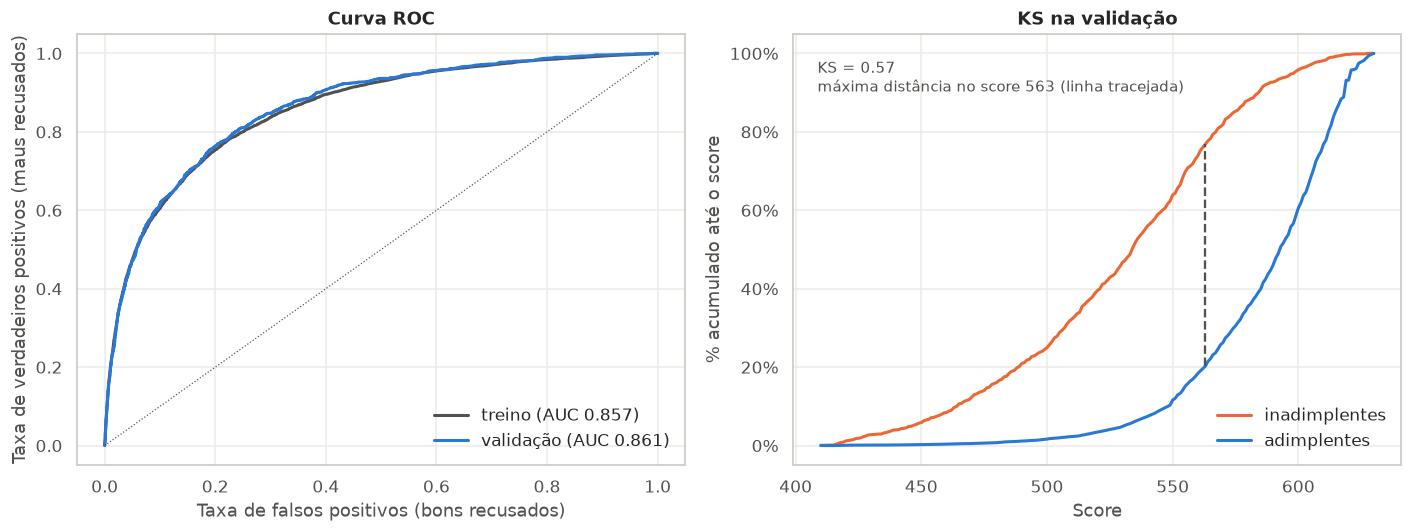

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for name, y, p, color in [("treino", y_train, p_train, GRAY), ("validação", y_val, p_val, BLUE)]:
    fpr, tpr, _ = roc_curve(y, p)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC {evaluate(y, p)['auc']:.3f})")
ax1.plot([0, 1], [0, 1], color=GRAY, lw=0.8, ls=":")
ax1.set_xlabel("Taxa de falsos positivos (bons recusados)")
ax1.set_ylabel("Taxa de verdadeiros positivos (maus recusados)")
ax1.set_title("Curva ROC")
ax1.legend(loc="lower right", frameon=False)

s_val = score(pipeline, val[SCORECARD_FEATURES])
grid = np.sort(s_val.unique())
cum_bad = np.searchsorted(np.sort(s_val[y_val == 1]), grid, side="right") / (y_val == 1).sum()
cum_good = np.searchsorted(np.sort(s_val[y_val == 0]), grid, side="right") / (y_val == 0).sum()
i = np.argmax(cum_bad - cum_good)
ax2.plot(grid, cum_bad, color=ORANGE, lw=2, label="inadimplentes")
ax2.plot(grid, cum_good, color=BLUE, lw=2, label="adimplentes")
ax2.vlines(grid[i], cum_good[i], cum_bad[i], color=GRAY, lw=1.5, ls="--")
ax2.text(0.04, 0.94, f"KS = {cum_bad[i] - cum_good[i]:.2f}\nmáxima distância no score {grid[i]:.0f} (linha tracejada)",
         transform=ax2.transAxes, color=GRAY, va="top", fontsize=10)
ax2.set_xlabel("Score")
ax2.set_ylabel("% acumulado até o score")
ax2.set_title("KS na validação")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax2.legend(loc="lower right", frameon=False)

fig.tight_layout()
savefig(fig, "logistic_roc_ks")
plt.show()

O desempenho no treino e na validação é praticamente o mesmo, então o modelo não está sobreajustado. Isso é esperado de uma regressão logística com poucas variáveis agrupadas em faixas.

O KS lê-se assim: no score onde a distância é máxima, já estão abaixo dele boa parte dos inadimplentes e uma fração bem menor dos adimplentes. É esse descolamento que permite recusar muitos maus sem recusar muitos bons. Para referência, no mercado um KS acima de 0,4 costuma ser considerado bom para modelos de concessão.

## 5. O scorecard

Uso a escala mais comum no mercado: **600 pontos equivalem a uma chance de 50 bons para cada mau, e cada 20 pontos a mais dobram essa chance**. Cada faixa de cada variável recebe um número de pontos, e o score de um cliente é só a soma dos pontos.

In [8]:
scorecard = build_scorecard(pipeline)
print(f"Escala: {BASE_SCORE} pontos = chance {BASE_ODDS}:1, PDO = {PDO}")
scorecard[["variável", "faixa", "n_treino", "taxa_default", "pontos"]].style.format(
    {"taxa_default": "{:.1%}", "n_treino": "{:,}"}
).hide(axis="index").bar(subset="pontos", color="#cfe0f5")

Escala: 600 pontos = chance 50:1, PDO = 20


variável,faixa,n_treino,taxa_default,pontos
revolving_util,<= 0,"7,658",3.0%,95
revolving_util,"(0, 0.05]","26,119",1.4%,109
revolving_util,"(0.05, 0.13]","15,861",2.0%,102
revolving_util,"(0.13, 0.23]","10,170",3.1%,95
revolving_util,"(0.23, 0.39]","10,762",4.6%,87
revolving_util,"(0.39, 0.5]","5,537",6.6%,80
revolving_util,"(0.5, 0.7]","7,996",9.6%,73
revolving_util,"(0.7, 0.9]","6,963",15.3%,64
revolving_util,"(0.9, 1]","11,628",19.3%,59
revolving_util,> 1,"2,306",36.8%,43


A tabela deixa bem visível o peso de cada fator. A maior amplitude de pontos está na utilização do rotativo e nos atrasos, e a menor em `real_estate_loans`. Os códigos 96/98 (faixa "Faltante" das colunas de atraso) são punidos nas três colunas ao mesmo tempo, o que coloca esses clientes entre os menores scores possíveis, de acordo com a taxa de default de mais de 50% que eles têm. Para um analista, isso é tão transparente quanto um modelo pode ser.

Um exemplo de como o score de uma proposta se forma:

In [9]:
example = val.loc[[val.index[0]], SCORECARD_FEATURES]
points = score_points(pipeline, example)
display(pd.concat({"valor": example.T.iloc[:, 0], "pontos": points.T.iloc[:, 0]}, axis=1))
print(f"score total: {points.sum(axis=1).iloc[0]}  |  "
      f"prob. de default estimada: {pipeline.predict_proba(example)[0, 1]:.1%}")

,valor,pontos
revolving_util,0.022,109
age,44.000,78
debt_ratio,0.007,84
late_30_59,0.000,88
late_60_89,0.000,83
late_90,0.000,86
real_estate_loans,0.000,76


score total: 604  |  prob. de default estimada: 1.7%


## 6. O score separa bem os grupos?

Divido a validação em 10 faixas de score com o mesmo número de pessoas. Se o modelo funciona, a taxa de default precisa cair a cada faixa, e as faixas de baixo precisam concentrar a maior parte dos inadimplentes.

,score_min,score_max,n,maus,taxa_default,%_maus_acumulado
faixa,,,,,,
1,410,538,2250,813,36.1%,54%
2,538,557,2250,257,11.4%,71%
3,557,571,2250,162,7.2%,82%
4,571,582,2250,99,4.4%,88%
5,582,591,2250,63,2.8%,93%
6,591,599,2250,37,1.6%,95%
7,599,605,2250,30,1.3%,97%
8,605,612,2250,22,1.0%,99%
9,612,619,2250,15,0.7%,100%


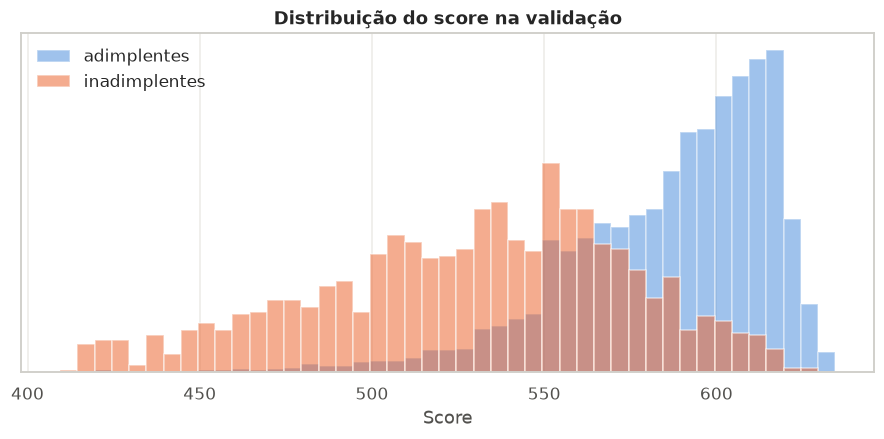

In [10]:
bands = band_table(y_val, s_val, n_bands=10)
display(bands.style.format({"taxa_default": "{:.1%}", "%_maus_acumulado": "{:.0%}", "score_min": "{:.0f}", "score_max": "{:.0f}"}))

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.arange(np.floor(s_val.min() / 5) * 5, s_val.max() + 6, 5) - 0.5  # faixas de 5 pontos alinhadas aos inteiros
ax.hist(s_val[y_val == 0], bins=bins, density=True, color=BLUE, alpha=0.45, label="adimplentes")
ax.hist(s_val[y_val == 1], bins=bins, density=True, color=ORANGE, alpha=0.55, label="inadimplentes")
ax.set_xlabel("Score")
ax.set_yticks([])
ax.set_title("Distribuição do score na validação")
ax.legend(frameon=False)
ax.grid(axis="y", visible=False)
savefig(fig, "logistic_score_distribution")
plt.show()

A taxa de default cai a cada faixa, da primeira à última. E a concentração é forte: só a primeira faixa, com os 10% de scores mais baixos, já reúne mais da metade dos inadimplentes. Na prática, isso já sugere a lógica do ponto de corte: recusar as faixas de baixo elimina muito risco perdendo relativamente poucos bons clientes. Quanto exatamente, e se compensa financeiramente, é o assunto do notebook de cutoff.

## 7. Salvando

O pipeline treinado vai para `models/`, o scorecard para `reports/` e as métricas para `reports/metrics.json`.

In [11]:
models_dir = ROOT / "models"
models_dir.mkdir(exist_ok=True)
joblib.dump(pipeline, models_dir / "logistic_woe.joblib")
scorecard.to_csv(ROOT / "reports" / "scorecard.csv", index=False)

update_metrics("logistic", {
    "features": SCORECARD_FEATURES,
    "train": {k: round(v, 4) for k, v in evaluate(y_train, p_train).items()},
    "val": {k: round(v, 4) for k, v in evaluate(y_val, p_val).items()},
    "scaling": {"base_score": BASE_SCORE, "base_odds": BASE_ODDS, "pdo": PDO},
})["logistic"]

{'features': ['revolving_util',
  'age',
  'debt_ratio',
  'late_30_59',
  'late_60_89',
  'late_90',
  'real_estate_loans'],
 'train': {'auc': 0.8565, 'gini': 0.713, 'ks': 0.5567},
 'val': {'auc': 0.8614, 'gini': 0.7227, 'ks': 0.5649},
 'scaling': {'base_score': 600, 'base_odds': 50, 'pdo': 20}}